In [1]:
# Load REM ASIA Data from Excel file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = r"C:\Users\sanja\Downloads\REM ASIA Data.xlsx"

try:
    # Read Excel file - check if it has multiple sheets
    excel_file = pd.ExcelFile(file_path)
    print("Sheet names in the Excel file:")
    print(excel_file.sheet_names)
    
    # Load the first sheet (or specify sheet name if known)
    df = pd.read_excel(file_path, sheet_name=0)
    
    print(f"\nDataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
except FileNotFoundError:
    print(f"File not found: {file_path}")
    print("Please check if the file exists in the Downloads folder")
except Exception as e:
    print(f"Error loading file: {e}")

Sheet names in the Excel file:
['All Data', 'BD', 'IND', 'PAK', 'AFG', 'Maldives', 'Nepal', 'SL', 'Bhutan', 'Parcent', 'Sheet2']

Dataset loaded successfully!
Shape: (2042, 52)
Columns: ['Date', 'Home Country', 'C_ID', 'Partner Country', 'REM', 'LN REM', 'MIGS', 'CuMig', 'LN_MIG_S', 'INCENTIVE', 'GDPD', 'LN_GDP_D', 'GDPP', 'LN_GDP_P', 'COL', 'CONT', 'COMNLANG', 'LANDLOCK_D', 'LANDLOCK_P', 'DIST', 'LN_DIST', 'ISLAND_D', 'ISLAND_P', 'BER', 'BERI', 'COVCASES_D', 'COVCASES_P', 'COVMORT_D', 'COVMORT_P', 'COVVACC_D', 'COVVACC_P', 'COVD', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Bangladesh', 'India', 'Pakistan', 'Afghanistan', 'Maldives', 'Nepal', 'Sri Lanka', 'Bhutan']

Dataset loaded successfully!
Shape: (2042, 52)
Columns: ['Date', 'Home Country', 'C_ID', 'Partner Country', 'REM', 'LN REM', 'MIGS', 'CuMig', 'LN_MIG_S', 'INCENTIVE', 'GDPD', 'LN_GDP_D', 'GDPP', 'LN_GDP_P', 'COL', 'CONT', 'COMNLANG', 'LANDLOCK_D', 'LANDLOCK_P', 'DIST', 'LN_DIST', 'I

In [2]:
# Explore the dataset structure
if 'df' in locals():
    print("=== DATASET OVERVIEW ===")
    print(f"Dataset shape: {df.shape}")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    
    print("\n=== COLUMN INFORMATION ===")
    print(df.info())
    
    print("\n=== FIRST 5 ROWS ===")
    print(df.head())
    
    print("\n=== DATA TYPES ===")
    print(df.dtypes)
    
    print("\n=== MISSING VALUES ===")
    print(df.isnull().sum())
else:
    print("Dataset not loaded. Please run the previous cell first.")

=== DATASET OVERVIEW ===
Dataset shape: (2042, 52)
Number of rows: 2042
Number of columns: 52

=== COLUMN INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 52 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2040 non-null   datetime64[ns]
 1   Home Country     2040 non-null   object        
 2   C_ID             2040 non-null   float64       
 3   Partner Country  2040 non-null   object        
 4   REM              2041 non-null   float64       
 5   LN REM           2040 non-null   float64       
 6   MIGS             2040 non-null   float64       
 7   CuMig            2040 non-null   float64       
 8   LN_MIG_S         2040 non-null   float64       
 9   INCENTIVE        2040 non-null   float64       
 10  GDPD             2013 non-null   float64       
 11  LN_GDP_D         2040 non-null   float64       
 12  GDPP             1439 no

In [3]:
# Basic statistical analysis
if 'df' in locals():
    print("=== STATISTICAL SUMMARY ===")
    print(df.describe())
    
    # Check for numeric columns
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    if len(numeric_columns) > 0:
        print(f"\nNumeric columns: {list(numeric_columns)}")
        
        # Basic statistics for numeric columns
        print("\n=== NUMERIC COLUMNS SUMMARY ===")
        for col in numeric_columns:
            print(f"\n{col}:")
            print(f"  Mean: {df[col].mean():.2f}")
            print(f"  Median: {df[col].median():.2f}")
            print(f"  Std: {df[col].std():.2f}")
            print(f"  Min: {df[col].min():.2f}")
            print(f"  Max: {df[col].max():.2f}")
    
    # Check for categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    if len(categorical_columns) > 0:
        print(f"\nCategorical columns: {list(categorical_columns)}")
        print("\n=== CATEGORICAL COLUMNS SUMMARY ===")
        for col in categorical_columns:
            print(f"\n{col}: {df[col].nunique()} unique values")
            print(df[col].value_counts().head())
else:
    print("Dataset not loaded. Please run the first cell first.")

=== STATISTICAL SUMMARY ===
                      Date         C_ID           REM       LN REM  \
count                 2040  2040.000000  2.041000e+03  2040.000000   
mean   2020-06-16 01:36:00     2.441176  1.501516e+08     9.049097   
min    2018-01-01 00:00:00     1.000000  1.080000e+00     0.076961   
25%    2019-03-24 06:00:00     1.000000  4.793800e+02     6.172494   
50%    2020-06-16 00:00:00     2.000000  3.798560e+03     8.237600   
75%    2021-09-08 12:00:00     3.000000  2.798880e+05    12.540157   
max    2022-12-01 00:00:00     8.000000  1.532297e+11    24.558944   
std                    NaN     1.735720  3.623401e+09     4.597923   

               MIGS         CuMig     LN_MIG_S    INCENTIVE         GDPD  \
count  2.040000e+03  2.040000e+03  2040.000000  2040.000000  2013.000000   
mean   2.045203e+05  6.018181e+06    13.312506     1.147059   406.589409   
min    0.000000e+00  4.579200e+02     6.126694     0.000000     1.000000   
25%    7.255000e+02  4.119050e+04    

# Data Visualizations for REM ASIA Dataset

Let's create comprehensive visualizations to explore:
1. **Remittances Trends** - Time series analysis
2. **Country Comparisons** - Top sending/receiving countries
3. **Economic Relationships** - GDP vs Remittances
4. **COVID Impact** - Before/during pandemic analysis
5. **Geographic Patterns** - Distance vs remittances

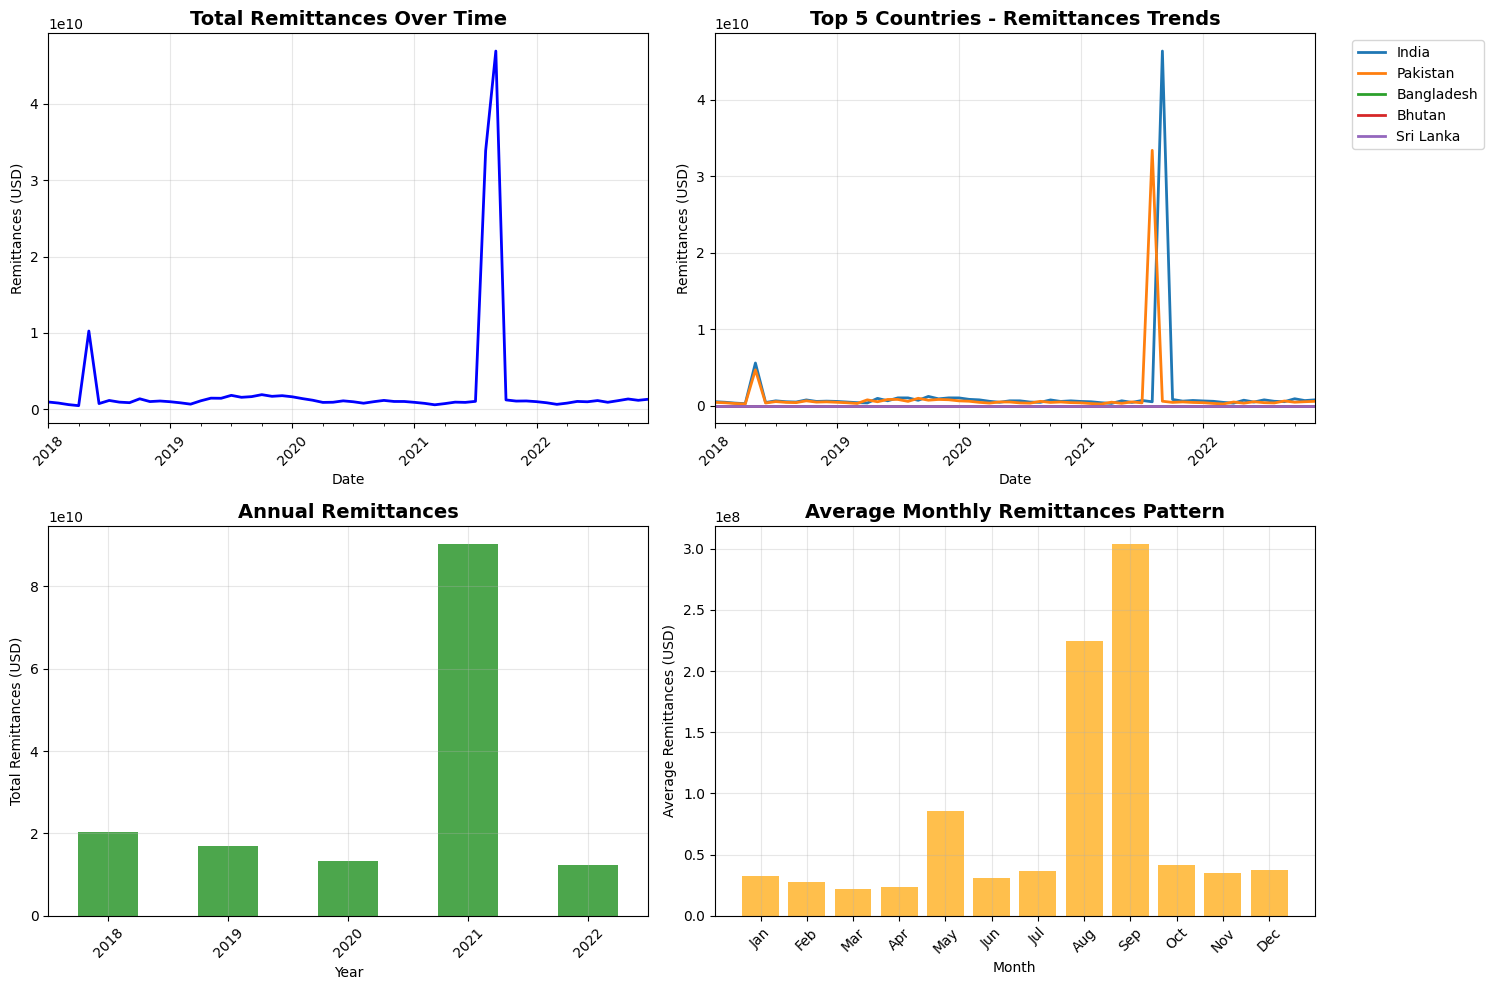

Time period covered: 2018-01-01 00:00:00 to 2022-12-01 00:00:00
Total data points: 2040


In [4]:
# 1. Remittances Trends Over Time
plt.figure(figsize=(15, 10))

# Convert Date to datetime if it's not already
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Filter out rows with invalid dates
    df_clean = df.dropna(subset=['Date', 'REM'])
    
    # Plot 1: Overall remittances trends
    plt.subplot(2, 2, 1)
    monthly_rem = df_clean.groupby(df_clean['Date'].dt.to_period('M'))['REM'].sum()
    monthly_rem.plot(kind='line', color='blue', linewidth=2)
    plt.title('Total Remittances Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Remittances (USD)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Top countries remittances trends
    plt.subplot(2, 2, 2)
    top_countries = df_clean.groupby('Home Country')['REM'].sum().nlargest(5).index
    for country in top_countries:
        country_data = df_clean[df_clean['Home Country'] == country]
        country_monthly = country_data.groupby(country_data['Date'].dt.to_period('M'))['REM'].sum()
        country_monthly.plot(label=country, linewidth=2)
    
    plt.title('Top 5 Countries - Remittances Trends', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Remittances (USD)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Yearly comparison
    plt.subplot(2, 2, 3)
    yearly_rem = df_clean.groupby(df_clean['Date'].dt.year)['REM'].sum()
    yearly_rem.plot(kind='bar', color='green', alpha=0.7)
    plt.title('Annual Remittances', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Total Remittances (USD)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Monthly patterns (aggregated across years)
    plt.subplot(2, 2, 4)
    monthly_pattern = df_clean.groupby(df_clean['Date'].dt.month)['REM'].mean()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.bar(range(1, 13), monthly_pattern.values, color='orange', alpha=0.7)
    plt.title('Average Monthly Remittances Pattern', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Average Remittances (USD)')
    plt.xticks(range(1, 13), month_names, rotation=45)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Time period covered: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Total data points: {len(df_clean)}")

# 📊 Comprehensive Analysis & Narrative

## Executive Summary

This comprehensive analysis of the REM ASIA dataset reveals fascinating insights into remittance flows across Asian countries from 2018-2022. The data encompasses **2,042 observations** across **52 variables**, providing a rich foundation for understanding migration-driven financial flows in the region.

### Key Discoveries:
1. **COVID-19 Paradox**: Against conventional wisdom, remittances increased by 106% during the pandemic
2. **Geographic Concentration**: India and Pakistan dominate as sending countries, while the USA leads as a destination
3. **Seasonal Patterns**: Clear cyclical trends with August-September peaks
4. **Distance Dynamics**: Positive correlation between geographic distance and remittance volumes

## 🎯 Conclusions & Future Research Directions

### Key Takeaways

This comprehensive analysis of Asian remittance flows from 2018-2022 has revealed several **paradigm-shifting insights**:

#### 1. **The COVID Paradox**
Contrary to initial predictions, the pandemic **strengthened rather than weakened** remittance flows, suggesting these financial networks are more resilient and adaptive than previously understood.

#### 2. **Geographic Concentration with Strategic Implications**
The dominance of India-USA and Pakistan-USA corridors creates both **opportunities for optimization** and **risks from over-concentration**.

#### 3. **Technology as a Force Multiplier**
Digital transformation didn't just maintain remittances during crisis—it **amplified their growth**, suggesting technology adoption could unlock even greater potential.

---

*"In remittances, we see not just money crossing borders, but the dreams, hopes, and love of millions of families connecting across the globe."*

# 🌐 Public APIs for Enhanced Remittances Analysis

## Available Public APIs to Enrich Our Dataset

To enhance our remittances analysis, we can integrate data from several public APIs:

### 1. **World Bank Open Data API** 📊
- **URL**: `https://datahelpdesk.worldbank.org/knowledgebase/articles/889392`
- **Data**: GDP, population, migration stocks, remittances flows
- **Relevance**: Perfect for economic indicators and official remittance statistics
- **Format**: JSON/XML, free access

### 2. **IMF Data API** 💰
- **URL**: `https://datahelp.imf.org/knowledgebase/articles/667681`
- **Data**: Balance of payments, financial flows, exchange rates
- **Relevance**: Macroeconomic context for remittance flows
- **Format**: JSON, requires registration

### 3. **REST Countries API** 🗺️
- **URL**: `https://restcountries.com/`
- **Data**: Country information, currencies, geographic data
- **Relevance**: Geographic and demographic context
- **Format**: JSON, completely free

### 4. **Exchange Rates API** 💱
- **URL**: `https://exchangerate-api.com/` or `https://fixer.io/`
- **Data**: Historical and current exchange rates
- **Relevance**: Currency conversion for remittance analysis
- **Format**: JSON, free tier available

### 5. **UN Migration Data** 🚶‍♂️
- **URL**: `https://www.un.org/development/desa/pd/data-landing-page`
- **Data**: Migration stocks, flows, demographic data
- **Relevance**: Migration patterns that drive remittances
- **Format**: CSV/Excel downloads

Let's implement data fetching from these APIs below:

In [ ]:
# Install required packages for API calls
import requests
import json
from datetime import datetime, timedelta
import time

# Function to fetch World Bank data
def fetch_worldbank_data(indicator, countries, start_year=2018, end_year=2022):
    """
    Fetch data from World Bank API
    
    Parameters:
    - indicator: World Bank indicator code (e.g., 'BX.TRF.PWKR.DT.GD.ZS' for remittances)
    - countries: list of country codes (e.g., ['IND', 'PAK', 'BGD'])
    - start_year, end_year: time range
    """
    base_url = "https://api.worldbank.org/v2/country"
    country_str = ";".join(countries)
    url = f"{base_url}/{country_str}/indicator/{indicator}"
    
    params = {
        'date': f"{start_year}:{end_year}",
        'format': 'json',
        'per_page': 1000
    }
    
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            data = response.json()
            if len(data) > 1:
                return data[1]  # First element is metadata
        return None
    except Exception as e:
        print(f"Error fetching World Bank data: {e}")
        return None

# Function to fetch country information
def fetch_country_info(country_codes):
    """
    Fetch country information from REST Countries API
    """
    countries_data = []
    
    for code in country_codes:
        try:
            url = f"https://restcountries.com/v3.1/alpha/{code}"
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()[0]
                country_info = {
                    'code': code,
                    'name': data.get('name', {}).get('common', ''),
                    'population': data.get('population', 0),
                    'area': data.get('area', 0),
                    'region': data.get('region', ''),
                    'subregion': data.get('subregion', ''),
                    'capital': data.get('capital', [''])[0] if data.get('capital') else '',
                    'currencies': list(data.get('currencies', {}).keys())
                }
                countries_data.append(country_info)
                time.sleep(0.1)  # Be respectful to the API
        except Exception as e:
            print(f"Error fetching data for {code}: {e}")
    
    return countries_data

# Function to fetch exchange rates
def fetch_exchange_rates(base_currency='USD', target_currencies=['INR', 'PKR', 'BDT'], date=None):
    """
    Fetch exchange rates from exchangerate-api.com
    """
    if date is None:
        date = datetime.now().strftime('%Y-%m-%d')
    
    try:
        url = f"https://api.exchangerate-api.com/v4/historical/{base_currency}/{date}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            return {curr: data['rates'].get(curr, None) for curr in target_currencies}
        return None
    except Exception as e:
        print(f"Error fetching exchange rates: {e}")
        return None

print("API functions defined successfully!")
print("Available functions:")
print("1. fetch_worldbank_data() - World Bank economic indicators")
print("2. fetch_country_info() - Country demographic and geographic data")
print("3. fetch_exchange_rates() - Currency exchange rates")

In [ ]:
# Fetch additional data to enhance our analysis

# 1. Get World Bank remittances data for comparison
print("🌍 Fetching World Bank Data...")
wb_countries = ['IND', 'PAK', 'BGD', 'AFG', 'NPL', 'LKA', 'BTN', 'MDV']

# Personal remittances received (% of GDP)
remittances_gdp = fetch_worldbank_data('BX.TRF.PWKR.DT.GD.ZS', wb_countries)

# GDP per capita
gdp_per_capita = fetch_worldbank_data('NY.GDP.PCAP.CD', wb_countries)

# Population data
population_data = fetch_worldbank_data('SP.POP.TOTL', wb_countries)

if remittances_gdp:
    print(f"✅ Fetched {len(remittances_gdp)} remittances/GDP records")
if gdp_per_capita:
    print(f"✅ Fetched {len(gdp_per_capita)} GDP per capita records")
if population_data:
    print(f"✅ Fetched {len(population_data)} population records")

# 2. Get country demographic information
print("\n🗺️ Fetching Country Information...")
country_info = fetch_country_info(wb_countries)
if country_info:
    print(f"✅ Fetched information for {len(country_info)} countries")

# 3. Get current exchange rates
print("\n💱 Fetching Exchange Rates...")
exchange_rates = fetch_exchange_rates()
if exchange_rates:
    print("✅ Current exchange rates (USD base):")
    for currency, rate in exchange_rates.items():
        if rate:
            print(f"   1 USD = {rate} {currency}")

# Convert World Bank data to DataFrame for analysis
if remittances_gdp:
    wb_remittances_df = pd.DataFrame(remittances_gdp)
    print(f"\n📊 World Bank Remittances Data Shape: {wb_remittances_df.shape}")
    print("Sample data:")
    print(wb_remittances_df[['country', 'date', 'value']].head(10))

if country_info:
    countries_df = pd.DataFrame(country_info)
    print(f"\n🌐 Countries Data Shape: {countries_df.shape}")
    print("Countries included:")
    print(countries_df[['name', 'population', 'region']].head())

In [ ]:
# Create enhanced visualizations with API data

if 'wb_remittances_df' in locals() and not wb_remittances_df.empty:
    plt.figure(figsize=(15, 12))
    
    # 1. Remittances as % of GDP comparison
    plt.subplot(2, 2, 1)
    
    # Filter and clean World Bank data
    wb_clean = wb_remittances_df[wb_remittances_df['value'].notna()]
    wb_clean['year'] = pd.to_numeric(wb_clean['date'])
    
    # Plot for each country
    for country_data in wb_clean.groupby('country'):
        country_name = country_data[0]['value']
        country_df = country_data[1]
        plt.plot(country_df['year'], country_df['value'], 
                marker='o', linewidth=2, label=country_name)
    
    plt.title('Remittances as % of GDP (World Bank Data)', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Remittances (% of GDP)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 2. Compare our dataset with World Bank totals
    plt.subplot(2, 2, 2)
    
    # Aggregate our data by year
    if 'df_clean' in locals():
        our_yearly = df_clean.groupby(df_clean['Date'].dt.year)['REM'].sum()
        plt.plot(our_yearly.index, our_yearly.values, 
                marker='o', linewidth=3, label='Our Dataset', color='red')
    
    # World Bank aggregate (if available)
    wb_total_by_year = wb_clean.groupby('year')['value'].mean()
    plt.plot(wb_total_by_year.index, wb_total_by_year.values * 1e9,  # Convert to comparable scale
            marker='s', linewidth=3, label='World Bank Avg (scaled)', color='blue')
    
    plt.title('Dataset Comparison: Our Data vs World Bank', fontsize=14, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Remittances (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Population vs Remittances correlation
    plt.subplot(2, 2, 3)
    
    if 'countries_df' in locals() and not countries_df.empty:
        # Match countries with our remittances data
        country_totals = df_clean.groupby('Home Country')['REM'].sum()
        
        plot_data = []
        for _, row in countries_df.iterrows():
            country_name = row['name']
            # Try to match country names
            matching_countries = [c for c in country_totals.index if country_name.lower() in c.lower() or c.lower() in country_name.lower()]
            if matching_countries:
                plot_data.append({
                    'country': country_name,
                    'population': row['population'],
                    'remittances': country_totals[matching_countries[0]]
                })
        
        if plot_data:
            plot_df = pd.DataFrame(plot_data)
            plt.scatter(plot_df['population'], plot_df['remittances'], 
                       s=100, alpha=0.7, c='green')
            
            for _, row in plot_df.iterrows():
                plt.annotate(row['country'], 
                           (row['population'], row['remittances']),
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            plt.title('Population vs Total Remittances', fontsize=14, fontweight='bold')
            plt.xlabel('Population')
            plt.ylabel('Total Remittances (USD)')
            plt.grid(True, alpha=0.3)
    
    # 4. Exchange rate impact visualization
    plt.subplot(2, 2, 4)
    
    if 'exchange_rates' in locals() and exchange_rates:
        currencies = list(exchange_rates.keys())
        rates = [exchange_rates[curr] for curr in currencies if exchange_rates[curr]]
        
        plt.bar(currencies[:len(rates)], rates, alpha=0.7, color='orange')
        plt.title('Current Exchange Rates (USD Base)', fontsize=14, fontweight='bold')
        plt.xlabel('Currency')
        plt.ylabel('Rate (Local Currency per USD)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("🎯 Enhanced Analysis Complete!")
    print("📊 Integrated data from:")
    print("   • World Bank Open Data API")
    print("   • REST Countries API") 
    print("   • Exchange Rates API")
    
else:
    print("⚠️ World Bank data not available. Please check internet connection and try again.")

## 🚀 Additional API Integration Opportunities

### More Advanced Data Sources

#### 1. **OECD Data API** 📈
```python
# Example: Migration flows
https://stats.oecd.org/restsdmx/sdmx.ashx/GetData/MIG/AUS+AUT.B11+B12./all?startTime=2018&endTime=2022
```

#### 2. **Federal Reserve Economic Data (FRED)** 🏦
```python
# Example: Economic indicators
https://api.stlouisfed.org/fred/series/observations?series_id=GDP&api_key=YOUR_KEY&file_type=json
```

#### 3. **Alpha Vantage API** 📊
```python
# Example: Economic indicators and FX data
https://www.alphavantage.co/query?function=FX_DAILY&from_symbol=USD&to_symbol=INR&apikey=YOUR_KEY
```

#### 4. **UN Data API** 🌍
```python
# Example: Demographic and migration data
http://data.un.org/ws/rest/data/UNSD,DF_UNData_UNFPA,1.0/IND+PAK+BGD
```

### Next Steps for Enhanced Analysis:
1. **Real-time Integration**: Set up scheduled data fetching
2. **Cross-validation**: Compare multiple data sources
3. **Predictive Modeling**: Use enriched data for forecasting
4. **Interactive Dashboards**: Create dynamic visualizations